In [73]:
# Load Metabarcoding/analysis/BarcodeBERT/results/barcodebert_results.pkl
import pickle
import pandas as pd
import numpy as np
with open("barcodebert_results.pkl", "rb") as f:
    results = pickle.load(f)
# Print the results
results

{'best_val_loss': 4.855507481331919,
 'predictions': array([0.01508192, 0.00553021, 0.00354544, ..., 0.00435255, 0.00141707,
        0.00084004], shape=(17252,), dtype=float32),
 'targets': array([0.0042735, 0.0042735, 0.0042735, ..., 0.       , 0.       ,
        0.       ], shape=(17252,), dtype=float32),
 'sample_labels': array(['G3D95R', 'G3D95R', 'G3D95R', ..., 'GZXAE6', 'GZXAE6', 'GZXAE6'],
       shape=(17252,), dtype='<U9'),
 'bin_labels': array(['BOLD:AAA2333', 'BOLD:AAA4996', 'BOLD:AAB1571', ...,
        'BOLD:AGR0227', 'BOLD:AGV6048', 'BOLD:AGZ0490'],
       shape=(17252,), dtype='<U12'),
 'latent_vector': array([ 2.8148215e+00, -5.3977048e-01, -1.7732370e-01, ...,
        -1.0859625e-03,  1.4890466e-03, -2.2928193e-03],
       shape=(64464,), dtype=float32),
 'train_losses': [(-1, 0, 5.1835628490821986),
  (-1, 1, 5.166936425601735),
  (-1, 2, 5.1626355133804624),
  (-1, 3, 5.160841708089791),
  (-1, 4, 5.158661225262811),
  (-1, 5, 5.157521752750172),
  (-1, 6, 5.156302910

In [74]:
results.keys()

dict_keys(['best_val_loss', 'predictions', 'targets', 'sample_labels', 'bin_labels', 'latent_vector', 'train_losses', 'val_losses', 'cycle_train_losses', 'cycle_val_losses', 'timeline_train_losses', 'timeline_val_losses'])

In [75]:
df = pd.DataFrame({'targets': results['targets'], 'predictions': results['predictions'], 'bin_labels': results['bin_labels'], 'sample_labels': results['sample_labels']})

In [85]:
stats_sample = pd.DataFrame()
stats_sample['Correlation'] = df.groupby('sample_labels').apply(lambda x: np.corrcoef(x['targets'], x['predictions'])[0, 1])
stats_sample['MAE'] = df.groupby('sample_labels').apply(lambda x: (np.abs(x['targets'] - x['predictions'])).mean()).sort_values()
stats_sample['MAE_zero_GT'] = df[df['targets'] == 0].groupby('sample_labels').apply(lambda x: (np.abs(x['targets'] - x['predictions'])).mean())
stats_sample['MAE_nonzero_GT'] = df[df['targets'] > 0].groupby('sample_labels').apply(lambda x: (np.abs(x['targets'] - x['predictions'])).mean())
stats_sample['KL_divergence'] = df.groupby('sample_labels').apply(lambda x: np.sum(x['targets'] * np.log(x['targets'] / (x['predictions'] + 1e-10))))
stats_sample['n_unique_bins'] = df.groupby('sample_labels')['bin_labels'].nunique()
stats_sample['percent_zero_GT'] = df.groupby('sample_labels').apply(lambda x: (x['targets'] == 0).mean() * 100)
stats_sample['median_target'] = df.groupby('sample_labels')['targets'].median()
stats_sample['mean_target'] = df.groupby('sample_labels')['targets'].mean()
stats_sample['max_target'] = df.groupby('sample_labels')['targets'].max()
stats_sample['std_target'] = df.groupby('sample_labels')['targets'].std()

/var/folders/k4/f_bpyr193w1dyd_9bdnnr3pc0000gn/T/ipykernel_6899/1547426928.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats_sample['Correlation'] = df.groupby('sample_labels').apply(lambda x: np.corrcoef(x['targets'], x['predictions'])[0, 1])
/var/folders/k4/f_bpyr193w1dyd_9bdnnr3pc0000gn/T/ipykernel_6899/1547426928.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats_sample['MAE'] = df.groupby('sample_

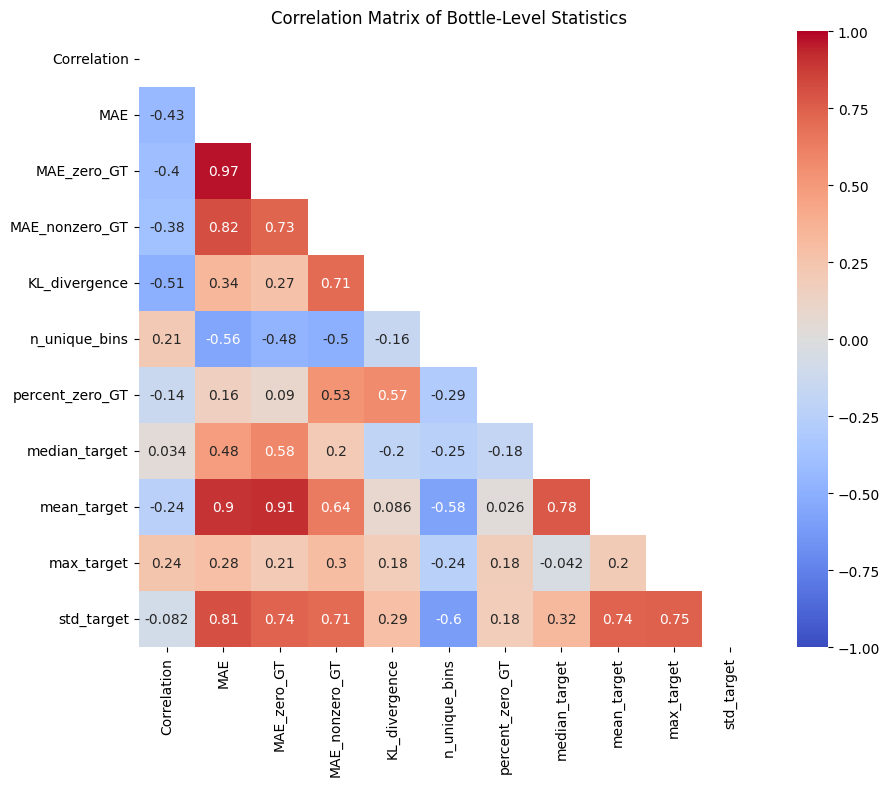

In [86]:
# Compute the correlation between all the stats
correlation_matrix = stats_sample.corr()
# Plot the correlation matrix as a heatmap (remove the diagonal and the upper triangle for better visualization)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, mask=np.triu(np.ones_like(correlation_matrix, dtype=bool)))
plt.title('Correlation Matrix of Bottle-Level Statistics')
plt.show()

In [80]:
stats_sample.sort_values(by='MAE_nonzero_GT', ascending=False)

,MAE,MAE_zero_GT,MAE_nonzero_GT,KL_divergence,n_unique_bins,percent_zero_GT,median_target,mean_target,max_target,std_target
sample_labels,,,,,,,,,,
GSTCUK,0.034256,0.026009,0.050160,1.368522,41,65.853659,0.000000,0.024390,0.272727,0.051923
GJOSZD,0.004056,0.002145,0.037146,2.151802,403,94.540943,0.000000,0.002481,0.162791,0.013547
GL1NOE,0.009203,0.005337,0.032583,1.304126,148,85.810811,0.000000,0.006757,0.129032,0.019643
GMP#16318,0.012663,0.006022,0.027657,1.286165,101,69.306931,0.000000,0.009901,0.289655,0.035907
GSKLXO,0.010385,0.005301,0.025051,0.992503,101,74.257426,0.000000,0.009901,0.224490,0.028515
GMP#41746,0.022512,0.021599,0.023367,0.506609,31,48.387097,0.055556,0.032258,0.111111,0.034469
G6UODR,0.014952,0.009870,0.018487,0.338105,39,41.025641,0.034483,0.025641,0.103448,0.027080
GMP#22039,0.004856,0.001213,0.015593,0.413624,150,74.666667,0.000000,0.006667,0.156250,0.018314
G8RL6E,0.008848,0.004823,0.014689,1.051530,125,59.200000,0.000000,0.008000,0.150538,0.017852


In [44]:
stats_bin = pd.DataFrame()
stats_bin['MAE'] = df.groupby('bin_labels').apply(lambda x: (np.abs(x['targets'] - x['predictions'])).mean()).sort_values()
stats_bin['MAE_zero_GT'] = df[df['targets'] == 0].groupby('bin_labels').apply(lambda x: (np.abs(x['targets'] - x['predictions'])).mean())
stats_bin['MAE_nonzero_GT'] = df[df['targets'] > 0].groupby('bin_labels').apply(lambda x: (np.abs(x['targets'] - x['predictions'])).mean())
stats_bin['KL_divergence'] = df.groupby('bin_labels').apply(lambda x: np.sum(x['targets'] * np.log(x['targets'] / (x['predictions'] + 1e-10))))
stats_bin['n_unique_samples'] = df.groupby('bin_labels')['sample_labels'].nunique()
stats_bin['percent_zero_GT'] = df.groupby('bin_labels').apply(lambda x: (x['targets'] == 0).mean() * 100)
stats_bin['median_target'] = df.groupby('bin_labels')['targets'].median()
stats_bin['mean_target'] = df.groupby('bin_labels')['targets'].mean()
stats_bin['max_target'] = df.groupby('bin_labels')['targets'].max()
stats_bin['std_target'] = df.groupby('bin_labels')['targets'].std()

/var/folders/k4/f_bpyr193w1dyd_9bdnnr3pc0000gn/T/ipykernel_6899/1712651614.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats_bin['MAE'] = df.groupby('bin_labels').apply(lambda x: (np.abs(x['targets'] - x['predictions'])).mean()).sort_values()
/var/folders/k4/f_bpyr193w1dyd_9bdnnr3pc0000gn/T/ipykernel_6899/1712651614.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats_bin['MAE_zero_GT'] = df[df['targets'

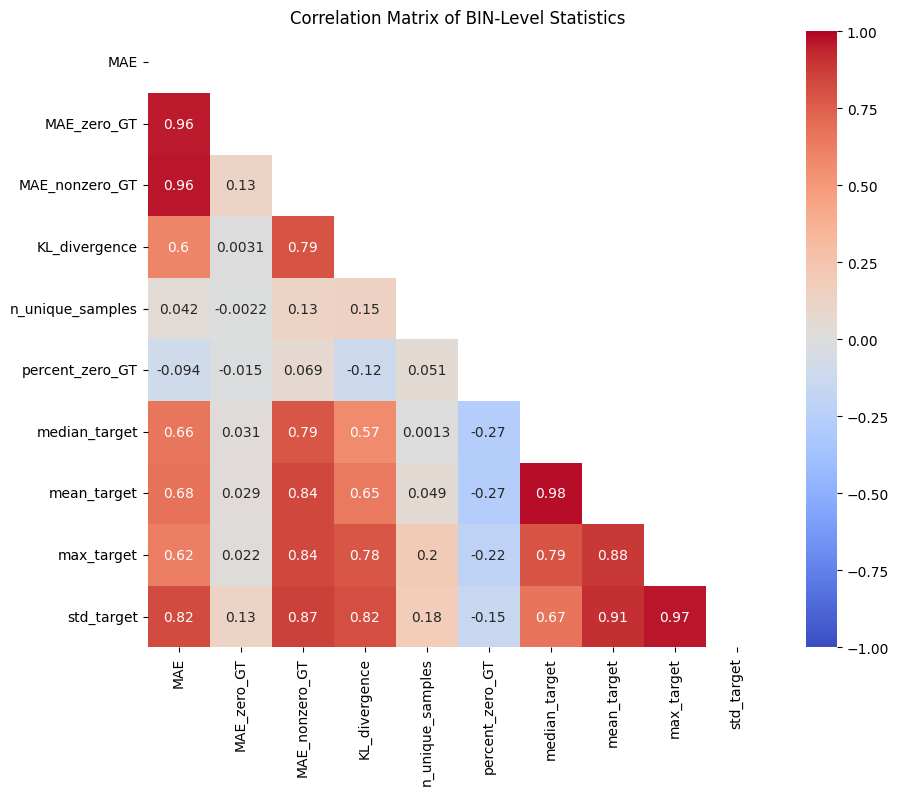

In [45]:
# Compute the correlation between all the stats
correlation_matrix = stats_bin.corr()
# Plot the correlation matrix as a heatmap (remove the diagonal and the upper triangle for better visualization)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, mask=np.triu(np.ones_like(correlation_matrix, dtype=bool)))
plt.title('Correlation Matrix of BIN-Level Statistics')
plt.show()

In [83]:
stats_bin.sort_values(by='n_unique_samples', ascending=False)

,MAE,MAE_zero_GT,MAE_nonzero_GT,KL_divergence,n_unique_samples,percent_zero_GT,median_target,mean_target,max_target,std_target
bin_labels,,,,,,,,,,
BOLD:AGB2107,0.000323,0.000323,NaN,0.000000,17,100.000000,0.000000,0.000000,0.000000,0.000000
BOLD:ACW3501,0.005528,0.000760,0.013871,0.115355,10,63.636364,0.000000,0.006539,0.032967,0.013068
BOLD:AAE8038,0.010702,0.009247,0.013610,-0.022249,9,66.666667,0.000000,0.002418,0.010811,0.004430
BOLD:AFA9414,0.000739,0.000451,0.001749,0.003997,9,77.777778,0.000000,0.001195,0.007519,0.002602
BOLD:ADZ1911,0.014042,0.000370,0.061892,0.304035,9,77.777778,0.000000,0.015532,0.084615,0.031687
...,...,...,...,...,...,...,...,...,...,...
BOLD:ACX3996,0.000469,NaN,0.000469,-0.000599,1,0.000000,0.000357,0.000357,0.000357,0.000000
BOLD:AGM0312,0.000469,0.000469,NaN,0.000000,1,100.000000,0.000000,0.000000,0.000000,NaN
BOLD:AEY6072,0.000469,NaN,0.000469,-0.000357,1,0.000000,0.000684,0.000684,0.000684,NaN


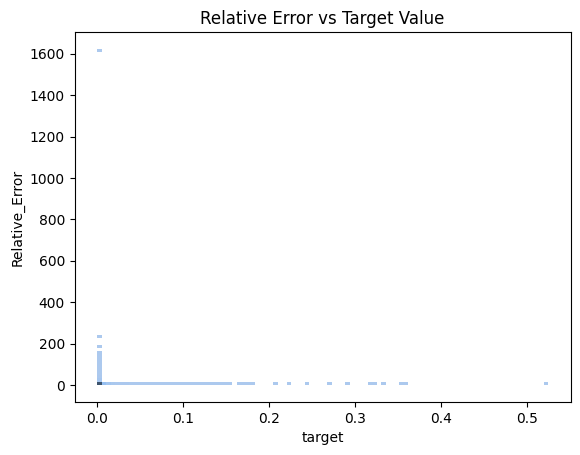

In [70]:
worst = pd.DataFrame({
    'MAE': np.abs(df['targets'] - df['predictions']),
    'Relative_Error': np.abs(df['targets'] - df['predictions']) / (df['targets'] + 10**(-3.5)),
    'target': df['targets'],
    'predictions': df['predictions'],
    'bin': df['bin_labels'],
    'sample': df['sample_labels']}).sort_values(by='Relative_Error', ascending=False)
sns.histplot(worst, x='target', y='Relative_Error', bins=100, log_scale=(False, False))
plt.title('Relative Error vs Target Value')
plt.show()

BOLD:AAR3985	0.041230
BOLD:AFD3896	0.037020
BOLD:AFQ9460	0.034738
BOLD:AAC4774	0.033072
BOLD:AFL3304	0.032485
BOLD:ABX9039	0.030182
BOLD:AFQ5521	0.024407
BOLD:AEV2696	0.023910
BOLD:ADL4383	0.019025
BOLD:AFO8853	0.014986

In [104]:
worst[worst['sample'] == 'GMP#41746'][['bin', 'predictions']].head(40)

,bin,predictions
14357,BOLD:AAR3985,0.041230
14371,BOLD:AFD3896,0.037020
14383,BOLD:AFQ9460,0.034738
14355,BOLD:AAC4774,0.033072
14374,BOLD:AFL3304,0.032485
14359,BOLD:ABX9039,0.030182
14382,BOLD:AFQ5521,0.024407
14370,BOLD:AEV2696,0.023910
14369,BOLD:ADL4383,0.019025
14379,BOLD:AFO8853,0.014986


In [87]:
worst.head(60)

,MAE,Relative_Error,target,predictions,bin,sample
16667,0.513302,1623.202881,0.0,0.513302,BOLD:AGK9144,GSTCUK
4506,0.073618,232.801697,0.0,0.073618,BOLD:AFU3856,GJBXW8
16620,0.061430,194.260269,0.0,0.061430,BOLD:AGL9295,GSKLXO
17186,0.058057,183.591232,0.0,0.058057,BOLD:AGI5046,GZXAE6
5463,0.050397,159.370346,0.0,0.050397,BOLD:AGK9219,GL1NOE
11555,0.046626,147.445343,0.0,0.046626,BOLD:AEX7258,GMP#22051
5440,0.045452,143.732193,0.0,0.045452,BOLD:AGI6993,GL1NOE
11364,0.043470,137.464096,0.0,0.043470,BOLD:AFA9401,GMP#22039
14357,0.041230,130.380341,0.0,0.041230,BOLD:AAR3985,GMP#41746
3107,0.037178,117.567772,0.0,0.037178,BOLD:AGG4218,GCJTHS
